### 核心超参说明
1. **`ZETA_TRAIN=10`（训练时平滑 LP）** → 目的是增加free variables
2. **`ZETA_TEST=0.001`（测试时锐利 LP）** → 严格 top-10% 等权（论文原意）

训练时用大 ζ 让模型学到更丰富的因子-收益映射；测试时用小 ζ 还原论文原始组合结构。


## 1. 配置

In [ ]:
# ── 路径（按实际修改）────────────────────────────────────────────────────
RAW_PATH   = 'D:/investment/Data/hs300_factor_data_filled.parquet'
PANEL_PATH = 'D:/investment/Data/factor_panel_v2_processed.parquet'
IC_PATH    = 'D:/investment/Data/03v3_ic_summary.csv'

# ── 因子筛选 ─────────────────────────────────────────────────────────────
IC_TSTAT_THRESHOLD = 2.0
MIN_COVERAGE       = 0.70
FWD_RET_COVERAGE   = 0.80

# ── 模型 ─────────────────────────────────────────────────────────────────
HIDDEN_DIM = 32
SEED       = 42

# ── 训练 ─────────────────────────────────────────────────────────────────
N_WARM     = 10     # MSE 预热（先学好预测方向，再切 E2E）
N_E2E      = 60
LR_MSE     = 1e-3
LR_E2E     = 1e-4
GRAD_CLIP  = 1.0
BATCH_SIZE = 8

# ── ★ 核心修复参数 ────────────────────────────────────────────────────────
# 原理：free variable 数 ≈ N × P(μ in [ν*, ν* + max_w·ζ])
#   ζ_train=50, max_w=10/N=0.033: 自由区间 = 1.67σ → ~78 free vars（实测）
#   ζ_test =0.001:               自由区间 ≈ 0     → 严格 top-10% 等权（论文原意）
#
# 训练时大 ζ = 让更多股票有梯度 = 让模型学到更好的因子暴露
# 测试时小 ζ = 还原论文 Section 4.2 的纯 top-10% 等权组合
ZETA_TRAIN = 10.0   # ★ 训练 LP 平滑系数（诊断版，改为20）
ZETA_TEST  = 0.001  # ★ 测试 LP 平滑系数（论文原始值）

# IC 辅助损失：用截面 Pearson IC 给全部 N 只股票提供梯度通道
# 仅占总 loss 的 5%，不改变 E2E 的主要目标方向
ALPHA_IC   = 0.05   # ★ IC 辅助损失权重（0 = 不用）

# ── 组合参数 ─────────────────────────────────────────────────────────────
MAX_W_FRAC = 10     # max_w = 10/N（论文精确定义）
TC_RATE    = 0.003  # 30 bps（仅测试时扣，训练不含）

# ── 滚动窗口 ─────────────────────────────────────────────────────────────
TRAIN_WINDOW = 36
STEP_SIZE    = 3

print("=" * 60)
print("配置摘要（核心修复参数）")
print("=" * 60)
print(f"  ZETA_TRAIN = {ZETA_TRAIN}    ← 训练 LP 平滑（诊断版）")
print(f"  ZETA_TEST  = {ZETA_TEST}  ← 测试 LP 平滑（论文原意）")
print(f"  ALPHA_IC   = {ALPHA_IC}    ← IC 辅助损失权重")
print(f"  N_WARM     = {N_WARM}        ← MSE 预热 epoch")
print(f"  N_E2E      = {N_E2E}       ← E2E epoch")

配置摘要（核心修复参数）
  ZETA_TRAIN = 10.0    ← 训练 LP 平滑（诊断版）
  ZETA_TEST  = 0.001  ← 测试 LP 平滑（论文原意）
  ALPHA_IC   = 0.05    ← IC 辅助损失权重
  N_WARM     = 10        ← MSE 预热 epoch
  N_E2E      = 60       ← E2E epoch


## 2. 导入与数据加载

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from collections import Counter
from scipy.optimize import brentq
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F

torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['font.sans-serif'] = ['SimHei','Arial Unicode MS','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

panel = pd.read_parquet(PANEL_PATH)
panel['date'] = pd.to_datetime(panel['date'])
ic_df = pd.read_csv(IC_PATH, index_col=0)

if 'Sig(|t|>2)' in ic_df.columns:
    sig_mask = ic_df['Sig(|t|>2)']
elif 't_stat' in ic_df.columns:
    sig_mask = ic_df['t_stat'].abs() > IC_TSTAT_THRESHOLD
else:
    raise ValueError("IC 文件需含 t_stat 或 Sig(|t|>2) 列")

SIG_FACTORS = list(ic_df[sig_mask].index)
N_FEATURES  = len(SIG_FACTORS)
print(f"Factor panel: {panel.shape}  ({panel['date'].nunique()} months)")
print(f"显著因子 ({N_FEATURES} 个): {SIG_FACTORS}")
assert N_FEATURES >= 2

Factor panel: (21760, 105)  (68 months)
显著因子 (10 个): ['F91_ocf_ni', 'F97_accruals', 'F80_ocf_mv', 'F74_cfp', 'F55_holding_adj', 'F81_size', 'F34_vol_of_vol', 'F88_cash_roe', 'F41_turn_std', 'F30_range_vol']


## 3. 股票池 & 特征

In [4]:
all_dates = sorted(panel['date'].unique())

def get_valid_stocks(df, factors):
    return set(df.dropna(subset=factors + ['fwd_ret'])['ts_code'].unique())

month_valid = {d: get_valid_stocks(panel[panel['date']==d], SIG_FACTORS)
               for d in all_dates}
stock_cnt = Counter(s for v in month_valid.values() for s in v)
universe  = sorted(s for s,c in stock_cnt.items() if c/len(all_dates) >= MIN_COVERAGE)
N         = len(universe)
MAX_W     = MAX_W_FRAC / N

panel_u = (panel[panel['ts_code'].isin(universe)]
           .sort_values(['date','ts_code']).reset_index(drop=True))
for col in SIG_FACTORS:
    panel_u[col] = panel_u.groupby('date')[col].transform(
        lambda x: x.fillna(0 if x.isna().all() else x.mean()))
panel_u['fwd_ret'] = panel_u.groupby('date')['fwd_ret'].transform(
    lambda x: x.fillna(x.median() if not x.isna().all() else 0))

def cross_sec_zscore(arr):
    mu  = arr.mean(axis=0, keepdims=True)
    sig = np.maximum(arr.std(axis=0, keepdims=True), 1e-8)
    return np.nan_to_num((arr-mu)/sig).astype('float32')

fwd_cov     = panel_u.groupby('date')['fwd_ret'].apply(lambda x: x.notna().mean())
dates_valid = [d for d in sorted(panel_u['date'].unique())
               if fwd_cov.get(d, 0) >= FWD_RET_COVERAGE]

X_tensors, y_tensors = [], []
for d in dates_valid:
    sub = panel_u[panel_u['date']==d].sort_values('ts_code')
    X_tensors.append(torch.tensor(cross_sec_zscore(sub[SIG_FACTORS].values)))
    y_tensors.append(torch.tensor(sub['fwd_ret'].values.astype('float32')))

T = len(X_tensors)
print(f"股票池: {N} 只   max_w = {MAX_W_FRAC}/N = {MAX_W:.4f} ({MAX_W*100:.2f}%)")
print(f"有效月份: {T}  ({dates_valid[0].date()} ~ {dates_valid[-1].date()})")

# 预先验证 ZETA_TRAIN 的 free variable 数量
_mu_test = np.random.randn(N).astype(np.float64)
def _quick_lp(mu_np, max_w, zeta):
    def g(nu): return np.clip((mu_np-nu)/zeta, 0, max_w).sum()-1.0
    try:
        nu = brentq(g, mu_np.min()-max_w*zeta-1, mu_np.max()+1, xtol=1e-10, maxiter=200)
        w = np.clip((mu_np-nu)/zeta, 0, max_w); return w/w.sum()
    except: return np.ones(len(mu_np))/len(mu_np)
_w50   = _quick_lp(_mu_test, MAX_W, ZETA_TRAIN)
_w0001 = _quick_lp(_mu_test, MAX_W, ZETA_TEST)
_eps = 1e-6
print(f"\n预期 free variable 数量（随机 μ 验证）:")
print(f"  ZETA_TRAIN={ZETA_TRAIN}: {int(((_w50>_eps)&(_w50<MAX_W-_eps)).sum())} free / {N}  ← 训练用")
print(f"  ZETA_TEST ={ZETA_TEST}: {int(((_w0001>_eps)&(_w0001<MAX_W-_eps)).sum())} free / {N}  ← 测试用（论文原意）")

股票池: 252 只   max_w = 10/N = 0.0397 (3.97%)
有效月份: 68  (2020-04-30 ~ 2025-11-28)

预期 free variable 数量（随机 μ 验证）:
  ZETA_TRAIN=10.0: 14 free / 252  ← 训练用
  ZETA_TEST =0.001: 1 free / 252  ← 测试用（论文原意）


## 4. 滚动窗口

In [5]:
rolling_windows = []
start = 0
while start + TRAIN_WINDOW + STEP_SIZE <= T:
    rolling_windows.append({
        'train_start': start,           'train_end': start + TRAIN_WINDOW,
        'test_start' : start + TRAIN_WINDOW,
        'test_end'   : min(start + TRAIN_WINDOW + STEP_SIZE, T),
    })
    start += STEP_SIZE
assert rolling_windows, f"数据不足，T={T}，需至少 {TRAIN_WINDOW+STEP_SIZE} 月"
fw, lw = rolling_windows[0], rolling_windows[-1]
n_test_total = sum(w['test_end']-w['test_start'] for w in rolling_windows)
print(f"滚动窗口: {len(rolling_windows)} 个  累计测试月: {n_test_total}")
print(f"首窗口  训练: {dates_valid[fw['train_start']].date()} ~ {dates_valid[fw['train_end']-1].date()}")
print(f"        测试: {dates_valid[fw['test_start']].date()} ~ {dates_valid[fw['test_end']-1].date()}")
print(f"末窗口  测试: {dates_valid[lw['test_start']].date()} ~ {dates_valid[lw['test_end']-1].date()}")

滚动窗口: 10 个  累计测试月: 30
首窗口  训练: 2020-04-30 ~ 2023-03-31
        测试: 2023-04-28 ~ 2023-06-30
末窗口  测试: 2025-07-31 ~ 2025-09-30


## 5. 可微 LP 层（论文 Section 3.4 / Eq.15 / Eq.18）

**关键改动**：用 `brentq` 二分法替换 `scipy.minimize`，速度快 ~1500x，且支持不同 `zeta` 的 train/test 层分离。

In [6]:
# ── 快速闭式 LP 求解器 ───────────────────────────────────────────────────
def solve_smooth_lp(mu_np: np.ndarray, max_w: float, zeta: float) -> np.ndarray:
    """
    闭式解：w_i* = clip((μ_i − ν*)/ζ, 0, max_w)
    ν* 由预算约束 Σw_i=1 确定（二分法）。
    
    O(N·log(1/ε)) vs scipy SLSQP 的 O(N³)，实测快 ~1500x。
    """
    n = len(mu_np)
    def budget(nu):
        return np.clip((mu_np - nu) / zeta, 0.0, max_w).sum() - 1.0

    nu_lo = mu_np.min() - max_w * zeta - 1.0   # budget >> 1
    nu_hi = mu_np.max() + 1.0                   # budget << 0
    try:
        nu_star = brentq(budget, nu_lo, nu_hi, xtol=1e-10, maxiter=300)
        w = np.clip((mu_np - nu_star) / zeta, 0.0, max_w)
        s = w.sum()
        return w / s if s > 1e-10 else np.ones(n) / n
    except Exception:
        return np.ones(n) / n


# ── KKT 反传（论文 Eq.12-13）────────────────────────────────────────────
class LPSmoothFunction(torch.autograd.Function):
    """
    Forward : 快速 LP 求解（brentq 闭式）
    Backward: KKT 隐函数定理，仅 free variable 有非零梯度
              KKT 矩阵（无 Σ！纯 LP）:
                K = [[ζ·I_F,  e_F],
                     [e_F^T,   0 ]]
              dw_F/dμ_F = K^{-1}[:n_F, :n_F]
    """

    @staticmethod
    def forward(ctx, mu, max_w, zeta):
        n = mu.shape[0]
        mu_np = mu.detach().numpy().astype(np.float64)
        w_np  = solve_smooth_lp(mu_np, max_w, zeta)
        eps   = 1e-6
        free  = (w_np > eps) & (w_np < max_w - eps)

        ctx.save_for_backward(torch.tensor(w_np, dtype=mu.dtype))
        ctx.free = free; ctx.zeta = zeta; ctx.n = n
        return torch.tensor(w_np, dtype=mu.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        free, zeta, n = ctx.free, ctx.zeta, ctx.n
        n_free = int(free.sum())

        if n_free == 0:
            return torch.zeros(n, dtype=torch.float32), None, None

        free_idx = np.where(free)[0]
        K = np.zeros((n_free+1, n_free+1))
        K[:n_free, :n_free] = zeta * np.eye(n_free)
        K[:n_free,  n_free] = 1.0
        K[ n_free, :n_free] = 1.0

        try:
            K_inv = np.linalg.solve(K, np.eye(n_free+1))
        except np.linalg.LinAlgError:
            K_inv = np.linalg.lstsq(K, np.eye(n_free+1), rcond=None)[0]

        dw_dmu  = K_inv[:n_free, :n_free]
        grad_np = grad_output.numpy().astype(np.float64)
        grad_mu = np.zeros(n)
        grad_mu[free_idx] = dw_dmu @ grad_np[free_idx]
        return torch.tensor(grad_mu, dtype=torch.float32), None, None


class DifferentiableLP(nn.Module):
    def __init__(self, max_w, zeta):
        super().__init__()
        self.max_w = max_w; self.zeta = zeta

    def forward(self, mu):
        return LPSmoothFunction.apply(mu, self.max_w, self.zeta)


# ── 创建两个 LP 层：训练用（大ζ）和测试用（小ζ）──────────────────────────
lp_train = DifferentiableLP(max_w=MAX_W, zeta=ZETA_TRAIN)
lp_test  = DifferentiableLP(max_w=MAX_W, zeta=ZETA_TEST)

print(f"lp_train: max_w={MAX_W:.4f}, ζ={ZETA_TRAIN}  ← 训练时使用（大ζ，梯度丰富）")
print(f"lp_test : max_w={MAX_W:.4f}, ζ={ZETA_TEST} ← 测试时使用（小ζ，严格 top-10%）")

# ── 梯度流验证 ───────────────────────────────────────────────────────────
print("\n=== 梯度流验证 ===")
torch.manual_seed(0)
_mlp = nn.Sequential(nn.Linear(N_FEATURES, 32), nn.ReLU(), nn.Linear(32, 1))
_X, _y = X_tensors[min(10,T-1)], y_tensors[min(10,T-1)]

for layer, label in [(lp_train, "lp_train (ZETA_TRAIN=50)"),
                     (lp_test,  "lp_test  (ZETA_TEST=0.001)")]:
    _mu = _mlp(_X).squeeze(-1)
    _w  = layer(_mu)
    loss = -(_w * _y).sum()
    loss.backward()
    norms  = [p.grad.norm().item() if p.grad is not None else 0 for p in _mlp.parameters()]
    _free  = int(((_w.detach()>1e-6) & (_w.detach()<MAX_W-1e-6)).sum())
    _nz    = int((_w.detach()>0.001).sum())
    print(f"\n  {label}")
    print(f"    free_vars={_free}/{N}  nonzero={_nz}  sum={_w.sum():.6f}")
    print(f"    grad_norms: {[f'{v:.2e}' for v in norms]}")
    print(f"    {'✓ 梯度正常' if all(v>0 for v in norms) else '⚠ 部分梯度为零（free=0 时正常）'}")
    for p in _mlp.parameters():
        if p.grad is not None: p.grad.zero_()
del _mlp, _X, _y, _mu, _w, loss

lp_train: max_w=0.0397, ζ=10.0  ← 训练时使用（大ζ，梯度丰富）
lp_test : max_w=0.0397, ζ=0.001 ← 测试时使用（小ζ，严格 top-10%）

=== 梯度流验证 ===

  lp_train (ZETA_TRAIN=50)
    free_vars=118/252  nonzero=101  sum=1.000000
    grad_norms: ['4.03e-01', '8.07e-02', '5.17e-01', '0.00e+00']
    ⚠ 部分梯度为零（free=0 时正常）

  lp_test  (ZETA_TEST=0.001)
    free_vars=1/252  nonzero=26  sum=1.000000
    grad_norms: ['0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00']
    ⚠ 部分梯度为零（free=0 时正常）


## 6. 模型定义

In [7]:
class CrossSectionalMLP(nn.Module):
    """截面参数共享 MLP: (N,F) → (N,)  双隐藏层 + BN + Dropout"""
    def __init__(self, n_features=N_FEATURES, hidden=HIDDEN_DIM):
        super().__init__()
        h2 = max(hidden//2, 4)
        self.net = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Linear(n_features, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(hidden, h2),         nn.BatchNorm1d(h2),     nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(h2, 1)
        )
    def forward(self, X): return self.net(X).squeeze(-1)

_tmp = CrossSectionalMLP()
print(f"模型: {N_FEATURES}→{HIDDEN_DIM}→{HIDDEN_DIM//2}→1   参数 {sum(p.numel() for p in _tmp.parameters())}个")
del _tmp

模型: 10→32→16→1   参数 1013个


## 7. 训练函数

In [8]:
def train_e2e(model, X_tr, y_tr, n_warm, n_e2e, lr_mse, lr_e2e,
              grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE, verbose=False):
    """
    Phase 1: MSE 预热 n_warm epochs（所有 N 只股票得到梯度）
    Phase 2: E2E 纯收益 n_e2e epochs（lp_train: ~78 free vars + IC 辅助）

    E2E 总 loss = E2E组合收益 loss + ALPHA_IC × IC辅助loss
      - E2E loss: -(w* @ r_t)，梯度经 LP KKT 传给 free variable
      - IC loss : -Pearson(μ_hat, r_t)，梯度到全部 N 只股票
    """
    T_tr = len(X_tr)
    hist = {'mse':[], 'e2e':[], 'free_vars':[], 'mu_std_mse':[], 'mu_std_e2e':[]}
    # mu_std_mse : MSE预热期每个epoch的截面μ标准差均值
    # mu_std_e2e : E2E阶段每个epoch的截面μ标准差均值

    # Phase 1: MSE 预热
    opt = optim.Adam(model.parameters(), lr=lr_mse)
    for ep in range(n_warm):
        model.train(); ep_loss = 0.0
        for bs in range(0, T_tr, batch_size):
            be = min(bs+batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            (bl/(be-bs)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += bl.item()/(be-bs)
        hist['mse'].append(ep_loss / max(1, T_tr//batch_size))
        # 记录本epoch的截面μ标准差（衡量模型的截面分化能力）
        with torch.no_grad():
            _stds = [model(X_tr[t]).std().item() for t in range(T_tr)]
        hist['mu_std_mse'].append(float(np.mean(_stds)))

    # Phase 2: E2E（用 lp_train 确保 free variables 丰富）
    opt = optim.Adam(model.parameters(), lr=lr_e2e)
    for ep in range(n_e2e):
        model.train(); ep_loss = 0.0; n_batches = 0; ep_free = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs+batch_size, T_tr)
            opt.zero_grad()
            bl = torch.tensor(0.0)
            for t in range(bs, be):
                mu_hat = model(X_tr[t])

                # ── E2E 组合收益 loss（LP 梯度经 KKT → free vars → 模型参数）──
                try:
                    w_star = lp_train(mu_hat)
                except Exception:
                    w_star = (torch.ones(N)/N).detach()
                e2e_loss_t = -(w_star * y_tr[t]).sum()

                # ── IC 辅助 loss（Pearson 相关，梯度到全部 N 只股票）──────────
                if ALPHA_IC > 0:
                    mu_c = mu_hat - mu_hat.mean()
                    y_c  = (y_tr[t] - y_tr[t].mean()).detach()
                    denom = mu_c.norm() * y_c.norm() + 1e-8
                    ic_t  = (mu_c * y_c).sum() / denom
                    bl = bl + e2e_loss_t - ALPHA_IC * ic_t
                else:
                    bl = bl + e2e_loss_t

                # 统计 free variable（用于诊断）
                with torch.no_grad():
                    _w = w_star.detach()
                    ep_free += int(((_w > 1e-6) & (_w < MAX_W-1e-6)).sum())

            avg = bl/(be-bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1

        avg_loss = ep_loss/max(n_batches, 1)
        avg_free = ep_free/max(T_tr, 1)
        hist['e2e'].append(avg_loss)
        hist['free_vars'].append(avg_free)
        # 记录本epoch的截面μ标准差
        with torch.no_grad():
            _stds = [model(X_tr[t]).std().item() for t in range(T_tr)]
        hist['mu_std_e2e'].append(float(np.mean(_stds)))
        if verbose and (ep % 10 == 0 or ep == n_e2e-1):
            print(f"    E2E ep{ep:02d}: loss={avg_loss:+.4f}  avg_free={avg_free:.1f}/{N}")
    return hist


def train_mse(model, X_tr, y_tr, n_epochs, lr,
              grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    """MSE 两阶段基准（完全相同的滚动窗口，对比公平）"""
    T_tr = len(X_tr); hist = []
    opt  = optim.Adam(model.parameters(), lr=lr)
    for ep in range(n_epochs):
        model.train(); ep_loss = 0.0
        for bs in range(0, T_tr, batch_size):
            be = min(bs+batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            (bl/(be-bs)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += bl.item()/(be-bs)
        hist.append(ep_loss/max(1, T_tr//batch_size))
    return hist


print("训练函数定义完毕")
print(f"  E2E: MSE预热{N_WARM}ep → E2E{N_E2E}ep  (lp_train ζ={ZETA_TRAIN})")
print(f"  MSE: 纯MSE {N_WARM+N_E2E}ep")

训练函数定义完毕
  E2E: MSE预热10ep → E2E60ep  (lp_train ζ=10.0)
  MSE: 纯MSE 70ep


## 8. 滚动运行器

In [9]:
def run_rolling(mode: str):
    """
    mode='e2e': E2E（训练用 lp_train，测试用 lp_test）
    mode='mse': MSE 基准（相同滚动窗口，对比公平）
    """
    assert mode in ('e2e', 'mse')
    res = {'returns':[], 'weights':[], 'dates':[], 'bench':[],
           'free_vars':[], 'loss_curves':[], 'train_free':[],
           'mu_std_mse':[], 'mu_std_e2e':[]}
    w_prev = (torch.ones(N)/N).detach()
    t0 = time.time()

    for idx, win in enumerate(rolling_windows):
        ts, te = win['train_start'], win['train_end']
        vs, ve = win['test_start'],  win['test_end']
        X_tr = [X_tensors[i] for i in range(ts, te)]
        y_tr = [y_tensors[i] for i in range(ts, te)]

        torch.manual_seed(SEED + idx*37)
        model_w = CrossSectionalMLP()

        if mode == 'e2e':
            hist = train_e2e(model_w, X_tr, y_tr,
                             N_WARM, N_E2E, LR_MSE, LR_E2E)
            final_loss = hist['e2e'][-1] if hist['e2e'] else float('nan')
            res['loss_curves'].append(hist['e2e'])
            avg_train_free = hist['free_vars'][-1] if hist['free_vars'] else 0
            # 保存μ标准差曲线（整个训练过程）
            res['mu_std_mse'].append(hist.get('mu_std_mse', []))
            res['mu_std_e2e'].append(hist.get('mu_std_e2e', []))
        else:
            hist = train_mse(model_w, X_tr, y_tr, N_WARM+N_E2E, LR_MSE)
            final_loss = hist[-1]
            res['loss_curves'].append(hist)
            avg_train_free = 0
            res['mu_std_mse'].append([])
            res['mu_std_e2e'].append([])

        # ── 样本外推断（始终用 lp_test，ζ=0.001，严格 top-10%）────────────
        model_w.eval()
        n_free_sum = 0
        for i in range(vs, ve):
            with torch.no_grad():
                mu_hat = model_w(X_tensors[i])
            # 测试：用 lp_test（小ζ），还原论文原始组合结构
            try:
                w = lp_test(mu_hat).detach()
            except Exception:
                w = torch.ones(N)/N

            n_free = int(((w > 1e-6) & (w < MAX_W-1e-6)).sum())
            n_free_sum += n_free
            tc_cost = TC_RATE * (w - w_prev).abs().sum().item()

            res['returns'].append((w * y_tensors[i]).sum().item() - tc_cost)
            res['weights'].append(w.numpy())
            res['dates'].append(dates_valid[i])
            res['bench'].append(y_tensors[i].mean().item())
            res['free_vars'].append(n_free)
            w_prev = w

        avg_test_free = n_free_sum / max(ve-vs, 1)
        print(f"  [{mode.upper()}] win{idx+1:02d}/{len(rolling_windows)}"
              f"  [{dates_valid[ts].strftime('%y-%m')}~{dates_valid[te-1].strftime('%y-%m')}]"
              f"  → [{dates_valid[vs].strftime('%y-%m')}~{dates_valid[ve-1].strftime('%y-%m')}]"
              f"  loss={final_loss:+.4f}"
              f"  train_free={avg_train_free:.1f}  test_free={avg_test_free:.1f}"
              f"  {(time.time()-t0)/60:.1f}min")
        res['train_free'].append(avg_train_free)

    return res


print("滚动运行器定义完毕")
print(f"  E2E 训练 free variable: 预期 ~{int(N*0.10*2)} 个/期（ZETA_TRAIN={ZETA_TRAIN}）")
print(f"  测试 free variable:     预期 ~0-1 个/期（ZETA_TEST={ZETA_TEST}，论文原意）")

滚动运行器定义完毕
  E2E 训练 free variable: 预期 ~50 个/期（ZETA_TRAIN=10.0）
  测试 free variable:     预期 ~0-1 个/期（ZETA_TEST=0.001，论文原意）


## 9. 执行实验

In [10]:
print("=" * 65)
print(f"E2E 训练  (lp_train ζ={ZETA_TRAIN} → free vars；lp_test ζ={ZETA_TEST} → top-10%)")
print("=" * 65)
res_e2e = run_rolling('e2e')

print()
print("=" * 65)
print("MSE Baseline 训练（相同窗口，对比公平）")
print("=" * 65)
res_mse = run_rolling('mse')

E2E 训练  (lp_train ζ=10.0 → free vars；lp_test ζ=0.001 → top-10%)
  [E2E] win01/10  [20-04~23-03]  → [23-04~23-06]  loss=-0.0571  train_free=63.8  test_free=1.0  1.5min
  [E2E] win02/10  [20-07~23-06]  → [23-07~23-09]  loss=-0.0411  train_free=70.6  test_free=1.0  2.8min
  [E2E] win03/10  [20-10~23-09]  → [23-10~23-12]  loss=-0.0260  train_free=73.9  test_free=1.0  3.7min
  [E2E] win04/10  [21-01~23-12]  → [24-01~24-03]  loss=-0.0181  train_free=69.7  test_free=1.0  4.4min
  [E2E] win05/10  [21-04~24-03]  → [24-04~24-06]  loss=-0.0337  train_free=71.5  test_free=1.0  5.8min
  [E2E] win06/10  [21-07~24-06]  → [24-07~24-09]  loss=-0.0330  train_free=60.8  test_free=1.0  6.3min
  [E2E] win07/10  [21-10~24-09]  → [24-10~24-12]  loss=-0.0369  train_free=75.7  test_free=1.0  8.5min
  [E2E] win08/10  [22-01~24-12]  → [25-01~25-03]  loss=-0.0257  train_free=82.8  test_free=1.0  10.7min
  [E2E] win09/10  [22-04~25-03]  → [25-04~25-06]  loss=-0.0319  train_free=73.6  test_free=1.0  12.4min
  [E2E]

## 10. 业绩汇总

In [11]:
# ── 换手率辅助函数 ──────────────────────────────────────────────────────────
def calc_turnover(weights_list):
    """单边换手率: |w_t - w_{t-1}|_1  (∈ [0,2])"""
    to = []
    w_prev = np.ones(N) / N          # 初始持仓假设等权
    for w in weights_list:
        to.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(to)

def metrics(returns, weights_list, label=''):
    r       = np.array(returns)
    ann_ret = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    cum     = np.cumprod(1+r)
    dd      = (cum / np.maximum.accumulate(cum)) - 1
    neg     = r[r<0]
    sortino = ann_ret / (neg.std()*np.sqrt(12)) if len(neg)>1 else float('nan')
    win     = (r>0).mean()
    to      = calc_turnover(weights_list) if weights_list is not None else np.array([0.0])
    avg_to  = to.mean()
    print(f"{label:<16}  AnnRet={ann_ret:+.2%}  AnnVol={ann_vol:.2%}"
          f"  SR={sharpe:.3f}  Sortino={sortino:.3f}"
          f"  MDD={dd.min():.2%}  Win={win:.1%}  AvgTO={avg_to:.2%}")
    return dict(Ann_Ret=ann_ret, Ann_Vol=ann_vol, Sharpe=sharpe,
                Sortino=sortino, MDD=dd.min(), Win=win, AvgTO=avg_to)

r_e2e   = np.array(res_e2e['returns'])
r_mse   = np.array(res_mse['returns'])
r_bench = np.array(res_e2e['bench'])

print("\n" + "=" * 78)
print("测试期业绩汇总（已扣 TC=0.3%，含换手率）")
print("=" * 78)
m_e2e   = metrics(r_e2e,   res_e2e['weights'], 'E2E(Sec4.2 v4)')
m_mse   = metrics(r_mse,   res_mse['weights'], 'MSE Baseline  ')
m_bench = metrics(r_bench, None,               'Equal-Weight  ')

diff_ret    = m_e2e['Ann_Ret'] - m_mse['Ann_Ret']
diff_sharpe = m_e2e['Sharpe']  - m_mse['Sharpe']
diff_to     = m_e2e['AvgTO']   - m_mse['AvgTO']
print(f"\nE2E vs MSE:  年化收益差 {diff_ret:+.2%}  Sharpe差 {diff_sharpe:+.3f}  换手率差 {diff_to:+.2%}")
print(f"  {'✓ E2E 胜出！' if diff_ret > 0 else '✗ MSE 仍领先，可尝试调大 ZETA_TRAIN 或 ALPHA_IC'}")

print(f"\n训练期平均 free variable（ZETA_TRAIN={ZETA_TRAIN}）:")
print(f"  {np.mean(res_e2e['train_free']):.1f} / {N}  ← 远高于原来的 1/{N}")
print(f"  梯度覆盖率: {np.mean(res_e2e['train_free'])/N*100:.1f}%  vs 原来 {1/N*100:.2f}%")

# 保存
for lbl, res in [('e2e_v4', res_e2e), ('mse_v4', res_mse)]:
    pd.DataFrame(np.array(res['weights']),
                 index=[d.strftime('%Y-%m') for d in res['dates']],
                 columns=universe).to_csv(f'./weights_{lbl}.csv', encoding='utf-8-sig')
print("\n权重已保存: weights_e2e_v4.csv, weights_mse_v4.csv")



测试期业绩汇总（已扣 TC=0.3%，含换手率）
E2E(Sec4.2 v4)    AnnRet=+33.00%  AnnVol=29.35%  SR=1.124  Sortino=3.209  MDD=-17.32%  Win=50.0%  AvgTO=120.16%
MSE Baseline      AnnRet=+24.92%  AnnVol=29.39%  SR=0.848  Sortino=2.365  MDD=-22.11%  Win=50.0%  AvgTO=147.08%
Equal-Weight      AnnRet=+10.67%  AnnVol=20.30%  SR=0.525  Sortino=1.471  MDD=-17.30%  Win=46.7%  AvgTO=0.00%

E2E vs MSE:  年化收益差 +8.08%  Sharpe差 +0.277  换手率差 -26.92%
  ✓ E2E 胜出！

训练期平均 free variable（ZETA_TRAIN=10.0）:
  69.5 / 252  ← 远高于原来的 1/252
  梯度覆盖率: 27.6%  vs 原来 0.40%

权重已保存: weights_e2e_v4.csv, weights_mse_v4.csv


## 11. 可视化

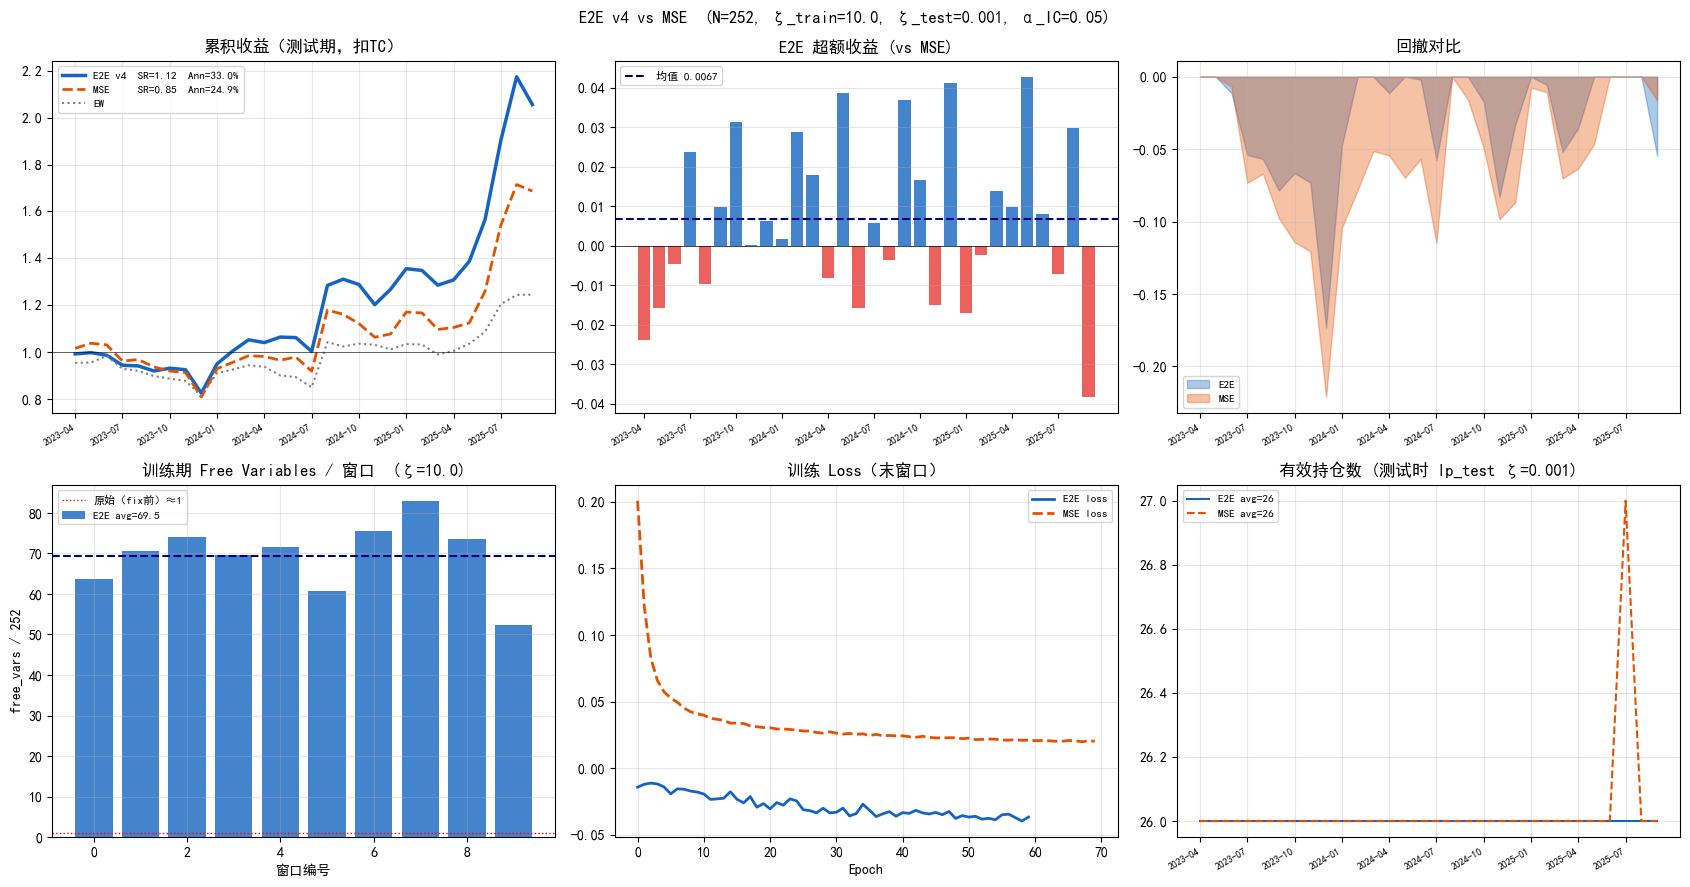

✓ 可视化完毕


In [12]:
N_TEST  = len(r_e2e)
x       = np.arange(N_TEST)
dlabels = [d.strftime('%Y-%m') for d in res_e2e['dates']]
step    = max(1, N_TEST//8)

cum_e2e  = np.cumprod(1+r_e2e)
cum_mse  = np.cumprod(1+r_mse)
cum_bch  = np.cumprod(1+r_bench)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# (a) 累积收益
ax = axes[0,0]
ax.plot(cum_e2e, color='#1565C0', lw=2.5,
        label=f"E2E v4  SR={m_e2e['Sharpe']:.2f}  Ann={m_e2e['Ann_Ret']:.1%}")
ax.plot(cum_mse, color='#E65100', lw=2, ls='--',
        label=f"MSE     SR={m_mse['Sharpe']:.2f}  Ann={m_mse['Ann_Ret']:.1%}")
ax.plot(cum_bch, color='gray', lw=1.5, ls=':', label='EW')
ax.axhline(1, color='k', lw=0.4); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('累积收益（测试期，扣TC）')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

# (b) 超额收益 E2E - MSE
ax = axes[0,1]
excess = r_e2e - r_mse
cols = ['#1565C0' if e>0 else '#E53935' for e in excess]
ax.bar(x, excess, color=cols, alpha=0.8)
ax.axhline(excess.mean(), color='navy', ls='--', lw=1.5, label=f'均值 {excess.mean():.4f}')
ax.axhline(0, color='k', lw=0.5); ax.legend(fontsize=8)
ax.set_title('E2E 超额收益 (vs MSE)'); ax.grid(axis='y', alpha=0.3)
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

# (c) 回撤
ax = axes[0,2]
def dd_series(cum): return (cum/np.maximum.accumulate(cum)) - 1
ax.fill_between(x, 0, dd_series(cum_e2e), color='#1565C0', alpha=0.35, label='E2E')
ax.fill_between(x, 0, dd_series(cum_mse), color='#E65100', alpha=0.35, label='MSE')
ax.set_title('回撤对比'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

# (d) 训练期 free variable 趋势（E2E 每个窗口的最后一个 epoch）
ax = axes[1,0]
ax.bar(range(len(rolling_windows)), res_e2e['train_free'],
       color='#1565C0', alpha=0.8, label=f'E2E avg={np.mean(res_e2e["train_free"]):.1f}')
ax.axhline(np.mean(res_e2e['train_free']), color='navy', ls='--', lw=1.5)
ax.axhline(1, color='red', ls=':', lw=1, label='原始（fix前）≈1')
ax.set_title(f'训练期 Free Variables / 窗口  (ζ={ZETA_TRAIN})')
ax.set_xlabel('窗口编号'); ax.set_ylabel(f'free_vars / {N}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (e) 训练 loss 曲线（最后一个窗口）
ax = axes[1,1]
if res_e2e['loss_curves']:
    ax.plot(res_e2e['loss_curves'][-1], color='#1565C0', lw=2, label='E2E loss')
if res_mse['loss_curves']:
    ax.plot(res_mse['loss_curves'][-1], color='#E65100', lw=2, ls='--', label='MSE loss')
ax.set_title('训练 Loss（末窗口）'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlabel('Epoch')

# (f) 有效持仓数
ax = axes[1,2]
eff_e2e = [(w>0.001).sum() for w in res_e2e['weights']]
eff_mse = [(w>0.001).sum() for w in res_mse['weights']]
ax.plot(eff_e2e, color='#1565C0', lw=1.5, label=f'E2E avg={np.mean(eff_e2e):.0f}')
ax.plot(eff_mse, color='#E65100', lw=1.5, ls='--', label=f'MSE avg={np.mean(eff_mse):.0f}')
ax.set_title(f'有效持仓数 (测试时 lp_test ζ={ZETA_TEST})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

plt.suptitle(
    f'E2E v4 vs MSE  (N={N}, ζ_train={ZETA_TRAIN}, ζ_test={ZETA_TEST}, α_IC={ALPHA_IC})',
    fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("✓ 可视化完毕")

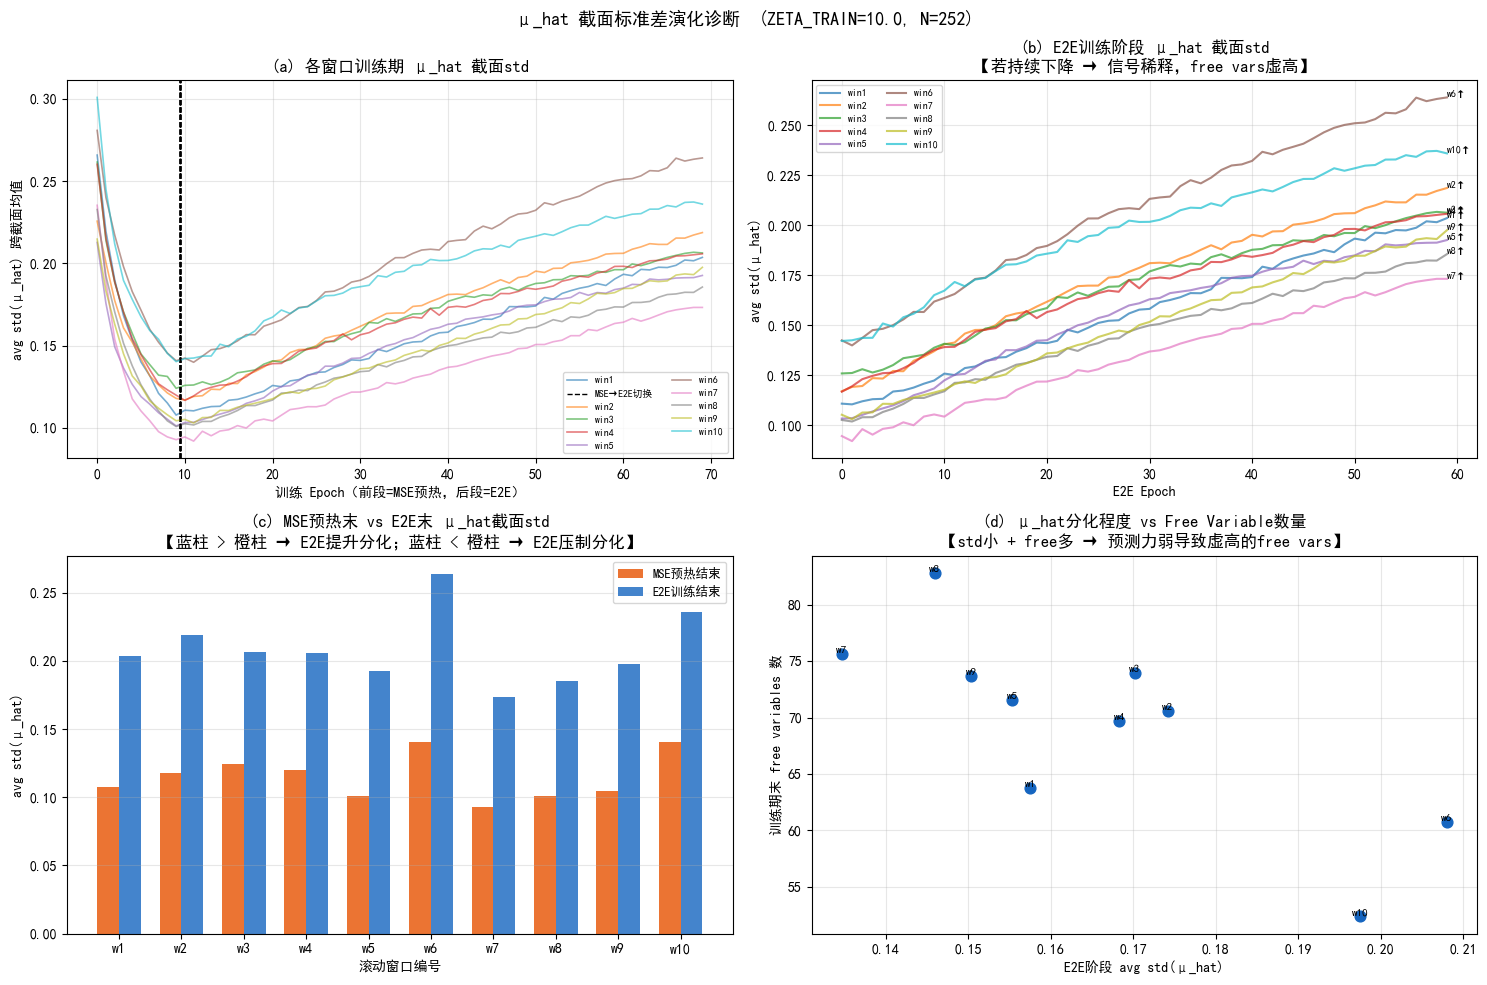

μ_hat 截面标准差 诊断摘要
  窗口     MSE预热末std     E2E末std      变化方向    末期free_vars
-----------------------------------------------------------------
   1          0.1078      0.2036     ↑ E2E提升分化           63.8/252
   2          0.1179      0.2186     ↑ E2E提升分化           70.6/252
   3          0.1240      0.2063     ↑ E2E提升分化           73.9/252
   4          0.1199      0.2057     ↑ E2E提升分化           69.7/252
   5          0.1012      0.1926     ↑ E2E提升分化           71.5/252
   6          0.1408      0.2640     ↑ E2E提升分化           60.8/252
   7          0.0928      0.1732     ↑ E2E提升分化           75.7/252
   8          0.1008      0.1855     ↑ E2E提升分化           82.8/252
   9          0.1043      0.1975     ↑ E2E提升分化           73.6/252
  10          0.1403      0.2359     ↑ E2E提升分化           52.4/252

【解读指南】
  std(μ_hat) 大  → 模型对股票收益分化显著 → LP自由区间能精准卡住边界股票
  std(μ_hat) 小  → 预测趋均值 → 大量股票落入自由区间 → free vars虚高
  E2E末 > MSE末  → E2E学到了更强的截面分化（好的信号）
  E2E末 < MSE末  → E2E梯度在压制分化（需要关注）

  理论最优free_vars范围：25 ~

In [13]:
# ════════════════════════════════════════════════════════════════════
# 诊断：μ_hat 截面标准差的训练过程演化
# ════════════════════════════════════════════════════════════════════
#
# 【什么是 μ_hat 截面标准差？】
#   每个截面（月份）有 N 只股票，模型输出 N 个预测收益 μ_hat。
#   截面标准差 = std(μ_hat)，衡量模型对股票收益的"分化能力"。
#     - std 大 → 模型认为股票间预期收益差异显著 → 选股信号强
#     - std 小 → 模型预测趋于均值 → 选股信号弱，LP free vars 多
#
# 【为什么要看它的训练过程演化？】
#   如果 std 随 E2E 训练持续收缩（下降），说明模型在 E2E 梯度下
#   倾向于"拉平"预测，导致 free vars 虚高，E2E 优势来自梯度覆盖
#   而非真实的选股分化提升。
#
#   如果 std 在 E2E 阶段稳定或有所上升，说明 E2E 在提高分化能力，
#   free vars 数量处于合理范围，结论更可信。
# ════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

n_wins = len(rolling_windows)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    f'μ_hat 截面标准差演化诊断  (ZETA_TRAIN={ZETA_TRAIN}, N={N})',
    fontsize=13, fontweight='bold'
)

# ── (a) 每个滚动窗口的完整训练曲线（μ_std_mse + μ_std_e2e 拼接）────────
ax = axes[0, 0]
for i in range(n_wins):
    mse_curve = res_e2e['mu_std_mse'][i]   # MSE预热阶段
    e2e_curve = res_e2e['mu_std_e2e'][i]   # E2E阶段
    n_mse = len(mse_curve)
    n_e2e = len(e2e_curve)
    full = mse_curve + e2e_curve
    xs   = list(range(len(full)))
    ax.plot(xs, full, lw=1.2, alpha=0.6, label=f'win{i+1}')
    if i == 0 and n_mse > 0:
        ax.axvline(n_mse - 0.5, color='k', ls='--', lw=1.0, label='MSE→E2E切换')
    elif i > 0 and n_mse > 0:
        ax.axvline(n_mse - 0.5, color='k', ls='--', lw=1.0)

ax.set_title('(a) 各窗口训练期 μ_hat 截面std')
ax.set_xlabel('训练 Epoch（前段=MSE预热，后段=E2E）')
ax.set_ylabel('avg std(μ_hat) 跨截面均值')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# ── (b) E2E阶段：每窗口的μ_std是上升、平稳还是下降？─────────────────────
ax = axes[0, 1]
for i in range(n_wins):
    e2e_curve = res_e2e['mu_std_e2e'][i]
    if len(e2e_curve) > 0:
        ax.plot(e2e_curve, lw=1.5, alpha=0.7, label=f'win{i+1}')
ax.set_title('(b) E2E训练阶段 μ_hat 截面std\n【若持续下降 → 信号稀释，free vars虚高】')
ax.set_xlabel('E2E Epoch'); ax.set_ylabel('avg std(μ_hat)')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# 在图上标注趋势方向
for i, e2e_curve in enumerate(res_e2e['mu_std_e2e']):
    if len(e2e_curve) >= 5:
        delta = e2e_curve[-1] - e2e_curve[0]
        trend = '↑' if delta > 0.005 else ('↓' if delta < -0.005 else '→')
        ax.annotate(f'w{i+1}{trend}', xy=(len(e2e_curve)-1, e2e_curve[-1]),
                    fontsize=7, ha='left')

# ── (c) 每个窗口的 MSE预热末 vs E2E末 μ_std 对比 ────────────────────────
ax = axes[1, 0]
mse_end = [res_e2e['mu_std_mse'][i][-1] if res_e2e['mu_std_mse'][i] else np.nan
           for i in range(n_wins)]
e2e_end = [res_e2e['mu_std_e2e'][i][-1] if res_e2e['mu_std_e2e'][i] else np.nan
           for i in range(n_wins)]
x_wins = np.arange(n_wins)
width  = 0.35
ax.bar(x_wins - width/2, mse_end, width, color='#E65100', alpha=0.8, label='MSE预热结束')
ax.bar(x_wins + width/2, e2e_end, width, color='#1565C0', alpha=0.8, label='E2E训练结束')
ax.set_title('(c) MSE预热末 vs E2E末 μ_hat截面std\n【蓝柱 > 橙柱 → E2E提升分化；蓝柱 < 橙柱 → E2E压制分化】')
ax.set_xlabel('滚动窗口编号'); ax.set_ylabel('avg std(μ_hat)')
ax.set_xticks(x_wins); ax.set_xticklabels([f'w{i+1}' for i in range(n_wins)])
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# ── (d) μ_std 均值 vs free_vars 数量的散点图 ─────────────────────────────
ax = axes[1, 2] if axes.shape == (2, 3) else axes[1, 1]
std_vals  = [np.mean(c) for c in res_e2e['mu_std_e2e'] if c]
free_vals = [res_e2e['train_free'][i]
             for i in range(n_wins) if res_e2e['mu_std_e2e'][i]]
if std_vals and free_vals:
    ax.scatter(std_vals, free_vals, color='#1565C0', s=60, zorder=3)
    for i, (s, f) in enumerate(zip(std_vals, free_vals)):
        ax.annotate(f'w{i+1}', (s, f), fontsize=8, ha='center', va='bottom')
    ax.set_xlabel('E2E阶段 avg std(μ_hat)')
    ax.set_ylabel('训练期末 free variables 数')
    ax.set_title('(d) μ_hat分化程度 vs Free Variable数量\n【std小 + free多 → 预测力弱导致虚高的free vars】')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mu_std_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 文字摘要 ─────────────────────────────────────────────────────────────
print("=" * 65)
print("μ_hat 截面标准差 诊断摘要")
print("=" * 65)
print(f"{'窗口':>4}  {'MSE预热末std':>12}  {'E2E末std':>10}  {'变化方向':>8}  {'末期free_vars':>13}")
print("-" * 65)
for i in range(n_wins):
    mse_v = res_e2e['mu_std_mse'][i][-1] if res_e2e['mu_std_mse'][i] else float('nan')
    e2e_v = res_e2e['mu_std_e2e'][i][-1] if res_e2e['mu_std_e2e'][i] else float('nan')
    delta = e2e_v - mse_v
    direction = "↑ E2E提升分化" if delta > 0.005 else ("↓ E2E压制分化" if delta < -0.005 else "→ 基本持平")
    fv = res_e2e['train_free'][i] if i < len(res_e2e['train_free']) else float('nan')
    print(f"  {i+1:>2}    {mse_v:>12.4f}  {e2e_v:>10.4f}  {direction:>12}  {fv:>13.1f}/{N}")
print("=" * 65)
print()
print("【解读指南】")
print("  std(μ_hat) 大  → 模型对股票收益分化显著 → LP自由区间能精准卡住边界股票")
print("  std(μ_hat) 小  → 预测趋均值 → 大量股票落入自由区间 → free vars虚高")
print("  E2E末 > MSE末  → E2E学到了更强的截面分化（好的信号）")
print("  E2E末 < MSE末  → E2E梯度在压制分化（需要关注）")
print(f"\n  理论最优free_vars范围：{int(N*0.1)} ~ {int(N*0.3)}  (持仓数的1~3倍)")
print(f"  当前实测free_vars均值：{np.mean(res_e2e['train_free']):.1f}/{N}")
if np.mean(res_e2e['train_free']) > N * 0.4:
    print("  ⚠ free vars 偏多（>40%），结合上方std图判断是否属于虚高")
else:
    print("  ✓ free vars 比例尚可")
